<a href="https://colab.research.google.com/github/AllanFabricio/linear_regression_water_quality_aracaju/blob/main/linear_regression_water_quality_aracaju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Preditiva: Impacto das Variáveis Meteorológicas na Balneabilidade Costeira de Aracaju

**Objetivo:** Este estudo documenta a rotina de processamento de dados e a modelagem estatística para investigar a relação entre variáveis meteorológicas e a balneabilidade das praias do município de Aracaju (SE). O projeto desenvolve modelos de Regressão Linear para estimar a concentração de coliformes fecais a partir de fatores climáticos.

**Reprodutibilidade e Fontes de Dados:**
Para assegurar a transparência científica, os conjuntos de dados utilizados foram extraídos de repositórios oficiais:
* **Dados Meteorológicos (INMET):** Instituto Nacional de Meteorologia (BDMEP). Disponível em: https://bdmep.inmet.gov.br/
* **Dados de Balneabilidade (ADEMA):** Administração Estadual do Meio Ambiente de Sergipe. Disponível em: https://adema.se.gov.br/balneabilidade-4/

> **Nota:** Os dados brutos foram previamente tratados e estruturados em tabelas no formato `.csv` para alimentar o modelo, garantindo o alinhamento das medições temporais.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Configurações globais
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# 1. Aquisição dos dados
df_inmet = pd.read_csv('dados_inmet_aracaju_2025.csv', sep=';')
df_adema = pd.read_csv('dados_adema_aracaju_2025.csv', sep=',')

# Limpeza dos nomes das colunas da ADEMA (remove quebras de linha e espaços extras)
df_adema.columns = df_adema.columns.str.replace('\n', ' ').str.replace('\r', '').str.strip()

# 2. Processamento da base climática (INMET)
df_inmet.replace('null', np.nan, inplace=True)
cols_medidas = df_inmet.columns[1:]
for col in cols_medidas:
    if df_inmet[col].dtype == object:
        df_inmet[col] = df_inmet[col].str.replace(',', '.').astype(float)

df_inmet['Data Medicao'] = pd.to_datetime(df_inmet['Data Medicao'])
df_inmet.ffill(inplace=True) # Preenchimento de lacunas (forward fill)

col_chuva = 'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)'

# Geração das variáveis de janela de precipitação
df_inmet['Prec_1d'] = df_inmet[col_chuva]
df_inmet['Prec_2d'] = df_inmet[col_chuva].rolling(window=2, min_periods=1).sum()
df_inmet['Prec_3d'] = df_inmet[col_chuva].rolling(window=3, min_periods=1).sum()
df_inmet['Prec_7d'] = df_inmet[col_chuva].rolling(window=7, min_periods=1).sum()

# 3. Processamento da base de balneabilidade (ADEMA)
df_adema['Data'] = pd.to_datetime(df_adema['Data'])
colunas_praias = [col for col in df_adema.columns if col != 'Data']

# Criar a média global para o teste inicial
df_adema['Media_Coliformes'] = df_adema[colunas_praias].mean(axis=1)

# 4. Sincronização temporal (Merge)
df_final = pd.merge(df_adema, df_inmet, left_on='Data', right_on='Data Medicao', how='inner')

# Aplicação da transformação Logarítmica para cada praia e para a média
df_final['Log_Media_Coliformes'] = np.log1p(df_final['Media_Coliformes'])
for praia in colunas_praias:
    df_final[f'Log_{praia}'] = np.log1p(df_final[praia])

print("ETL Concluído. Dados prontos para os testes.")

ETL Concluído. Dados prontos para os testes.


## 1. Testes de Variáveis e Justificativa Teórica

Antes de aplicar os modelos às praias individuais, é necessário definir o comportamento matemático ideal das nossas variáveis.

**I. Janela de Precipitação Acumulada**
Estudos sobre drenagem urbana e balneabilidade (ver Hirai e Porto, 2016; Silva Neto, 2017) indicam que a contaminação marinha não ocorre instantaneamente com a chuva. Existe um tempo de carreamento (escoamento superficial e saturação de galerias pluviais) que leva a carga bacteriana do continente para o mar. Vamos testar o impacto imediato (1 dia) contra impactos defasados e acumulados (2, 3 e 7 dias).

**II. Transformação Logarítmica**
Conforme amplamente documentado na literatura científica (Jabrane et al., 2022; Araújo, Melo e Diniz, 2011; Silva Neto, 2017), dados microbiológicos apresentam crescimento populacional exponencial e variância extrema. Picos de contaminação (ex: 1.300 NMP/100mL) esmagam medições normais (ex: 10 NMP/100mL). A aplicação do Logaritmo ($Log(x+1)$) lineariza a relação e homogeneíza a variância dos resíduos, premissa fundamental para a Regressão Linear. Vamos validar isso empiricamente comparando o modelo com e sem Log.

ARAÚJO, A. L. C. de; MELO, L. E. L. de; DINIZ, R. F. A influência da estação chuvosa na balneabilidade das praias do Rio Grande do Norte. In: CONGRESSO BRASILEIRO DE ENGENHARIA SANITÁRIA E AMBIENTAL, 26., 2011, Porto Alegre. Anais... Rio de Janeiro: ABES, 2011.

CASTRO, H. M. P. de. Efeito da radiação solar e da salinidade sobre o crescimento de Escherichia coli. 2003. Dissertação (Mestrado) - Universidade Federal do Ceará, Fortaleza, 2003.

HIRAI, F. M.; PORTO, M. F. do A. O desenvolvimento de ferramentas de predição de balneabilidade baseadas em níveis de precipitação: estudo de caso da praia de Cachoeira das Emas (SP). Engenharia Sanitária e Ambiental, Rio de Janeiro, v. 21, n. 4, p. 797-806, out./dez. 2016.

JABRANE, M. et al. Data Conditioning Modes for the Study of Groundwater Resource Quality Using a Large Physico-Chemical and Bacteriological Database, Occitanie Region, France. Water, v. 15, n. 1, p. 84, 2022. Disponível em: https://www.mdpi.com/2073-4441/15/1/84. Acesso em: 23 jun. 2026.

SILVA NETO, W. A. da. Aplicação de um modelo de regressão linear aos dados de balneabilidade das praias de Natal entre 2011 e 2015. 2017. 66 f. Trabalho de Conclusão de Curso (Bacharelado em Estatística) - Universidade Federal do Rio Grande do Norte, Natal, 2017.

VAZQUEZ, K. M. et al. Parsimonious Mechanistic Modeling of Bacterial Runoff into Irrigation Ponds To Inform Food Safety Management of Agricultural Water Quality. Applied and Environmental Microbiology, v. 87, n. 15, e00596-21, 2021. Disponível em: https://journals.asm.org/doi/10.1128/aem.00596-21. Acesso em: 23 jun. 2026.

--- TESTE 1: CORRELAÇÃO DE PEARSON (Precipitação vs Log Média Coliformes) ---
Correlação Prec_1d: 0.2416
Correlação Prec_2d: 0.2582
Correlação Prec_3d: 0.1946
Correlação Prec_7d: 0.2736

--- TESTE 2: EFICIÊNCIA DO LOGARITMO (R-Quadrado) ---
R² Sem Transformação (Dados Brutos): 0.0672
R² Com Transformação Logarítmica:   0.0748


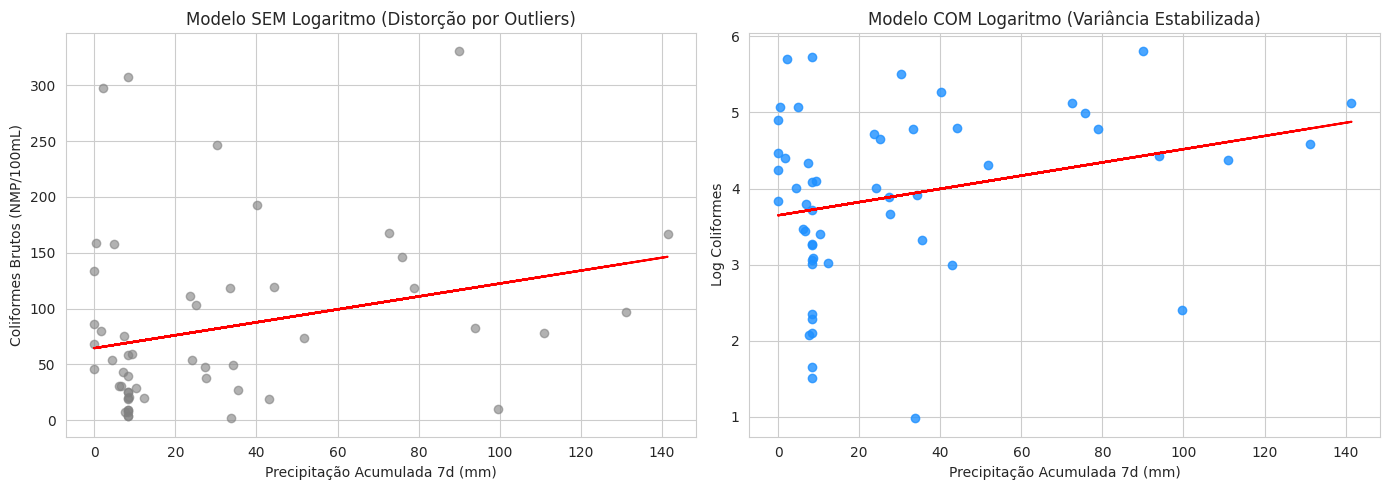

In [ ]:
# ==========================================
# TESTE 1: Avaliação da Janela de Precipitação
# ==========================================
print("--- TESTE 1: CORRELAÇÃO DE PEARSON (Precipitação vs Log Média Coliformes) ---")
janelas = ['Prec_1d', 'Prec_2d', 'Prec_3d', 'Prec_7d']
for janela in janelas:
    corr = df_final[janela].corr(df_final['Log_Media_Coliformes'])
    print(f"Correlação {janela}: {corr:.4f}")

# ==========================================
# TESTE 2: Impacto da Transformação Logarítmica
# ==========================================
# Selecionando a janela com base teórica/prática (usaremos 7 dias como baseline acumulada)
X_test = df_final[['Prec_7d']].values

# Y sem Log (Bruto)
y_bruto = df_final['Media_Coliformes'].values
mod_bruto = LinearRegression().fit(X_test, y_bruto)
r2_bruto = r2_score(y_bruto, mod_bruto.predict(X_test))

# Y com Log
y_log = df_final['Log_Media_Coliformes'].values
mod_log = LinearRegression().fit(X_test, y_log)
r2_log = r2_score(y_log, mod_log.predict(X_test))

print("\n--- TESTE 2: EFICIÊNCIA DO LOGARITMO (R-Quadrado) ---")
print(f"R² Sem Transformação (Dados Brutos): {r2_bruto:.4f}")
print(f"R² Com Transformação Logarítmica:   {r2_log:.4f}")

# Plotagem comparativa do efeito do Log
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Sem Log
axes[0].scatter(X_test, y_bruto, color='gray', alpha=0.6)
axes[0].plot(X_test, mod_bruto.predict(X_test), color='red')
axes[0].set_title('Modelo SEM Logaritmo (Distorção por Outliers)')
axes[0].set_ylabel('Coliformes Brutos (NMP/100mL)')
axes[0].set_xlabel('Precipitação Acumulada 7d (mm)')

# Gráfico 2: Com Log
axes[1].scatter(X_test, y_log, color='dodgerblue', alpha=0.8)
axes[1].plot(X_test, mod_log.predict(X_test), color='red')
axes[1].set_title('Modelo COM Logaritmo (Variância Estabilizada)')
axes[1].set_ylabel('Log Coliformes')
axes[1].set_xlabel('Precipitação Acumulada 7d (mm)')

plt.tight_layout()
plt.show()

## 2. Análise Exploratória por Ponto de Monitoramento (Praias)

Com as variáveis validadas (utilizando Precipitação de 7 dias e Transformação Logarítmica), a análise passa a focar na granularidade dos dados. O limite de alerta do CONAMA (1.000 NMP/100 mL) será utilizado como referência visual.

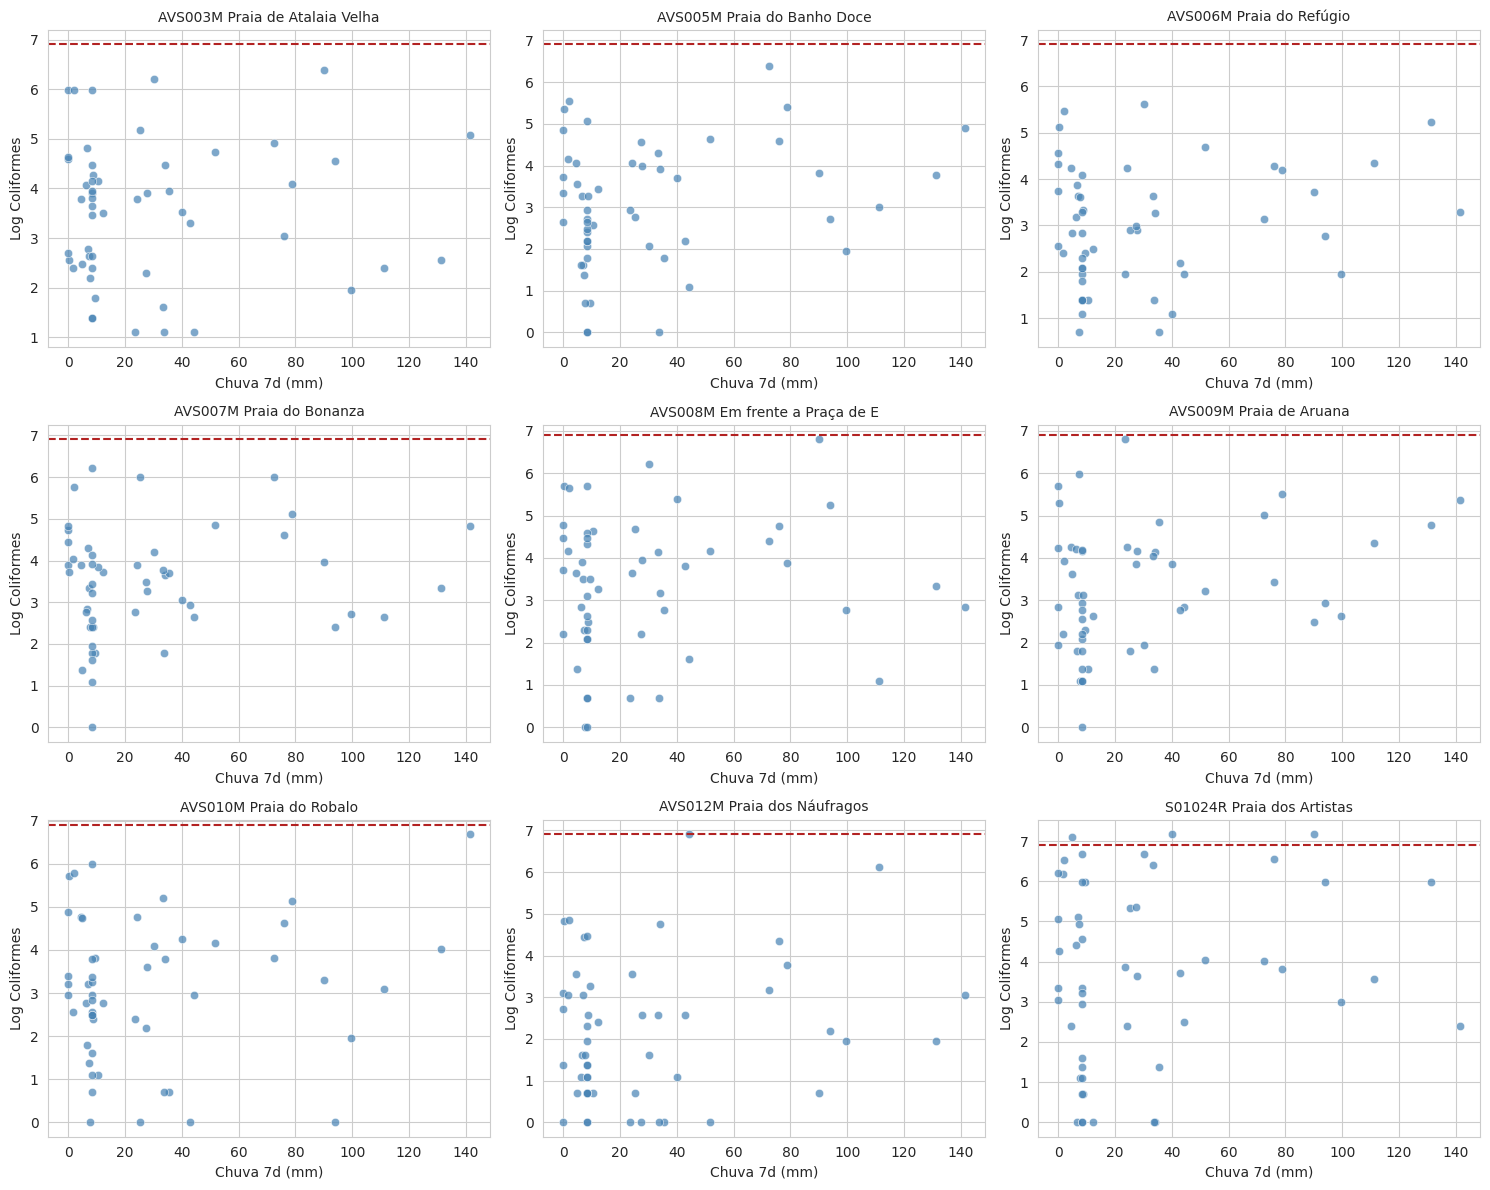

In [ ]:
# Gráfico de Dispersão: Praias Individuais
fig = plt.figure(figsize=(15, 12))
num_praias = len(colunas_praias)
cols = 3
rows = int(np.ceil(num_praias / cols))

limiar_conama_log = np.log1p(1000)

for i, praia in enumerate(colunas_praias, 1):
    ax = fig.add_subplot(rows, cols, i)

    x = df_final['Prec_7d']
    y = df_final[f'Log_{praia}']

    # Scatter dos pontos
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.7, color='steelblue')

    # Limiar Conama
    ax.axhline(y=limiar_conama_log, color='firebrick', linestyle='--', linewidth=1.5)

    # Limpando o nome da praia
    nome_curto = praia.split('-')[0].strip() + " " + praia.split('–')[0].split('-')[-1].strip()
    ax.set_title(nome_curto[:30], fontsize=10)
    ax.set_xlabel('Chuva 7d (mm)')
    ax.set_ylabel('Log Coliformes')

plt.tight_layout()
plt.show()

## 3. Modelo de Regressão Linear Simples por Praia

Para mensurar o impacto isolado do escoamento superficial em cada ponto de monitoramento da orla, estabelecemos o *baseline* algorítmico individual. O painel exibe a dispersão dos dados reais confrontada com a reta de regressão linear calculada para cada praia, permitindo identificar visualmente a sensibilidade local à precipitação acumulada de 7 dias.

--- PROCESSANDO REGRESSÃO LINEAR SIMPLES E GERANDO GRÁFICOS ---


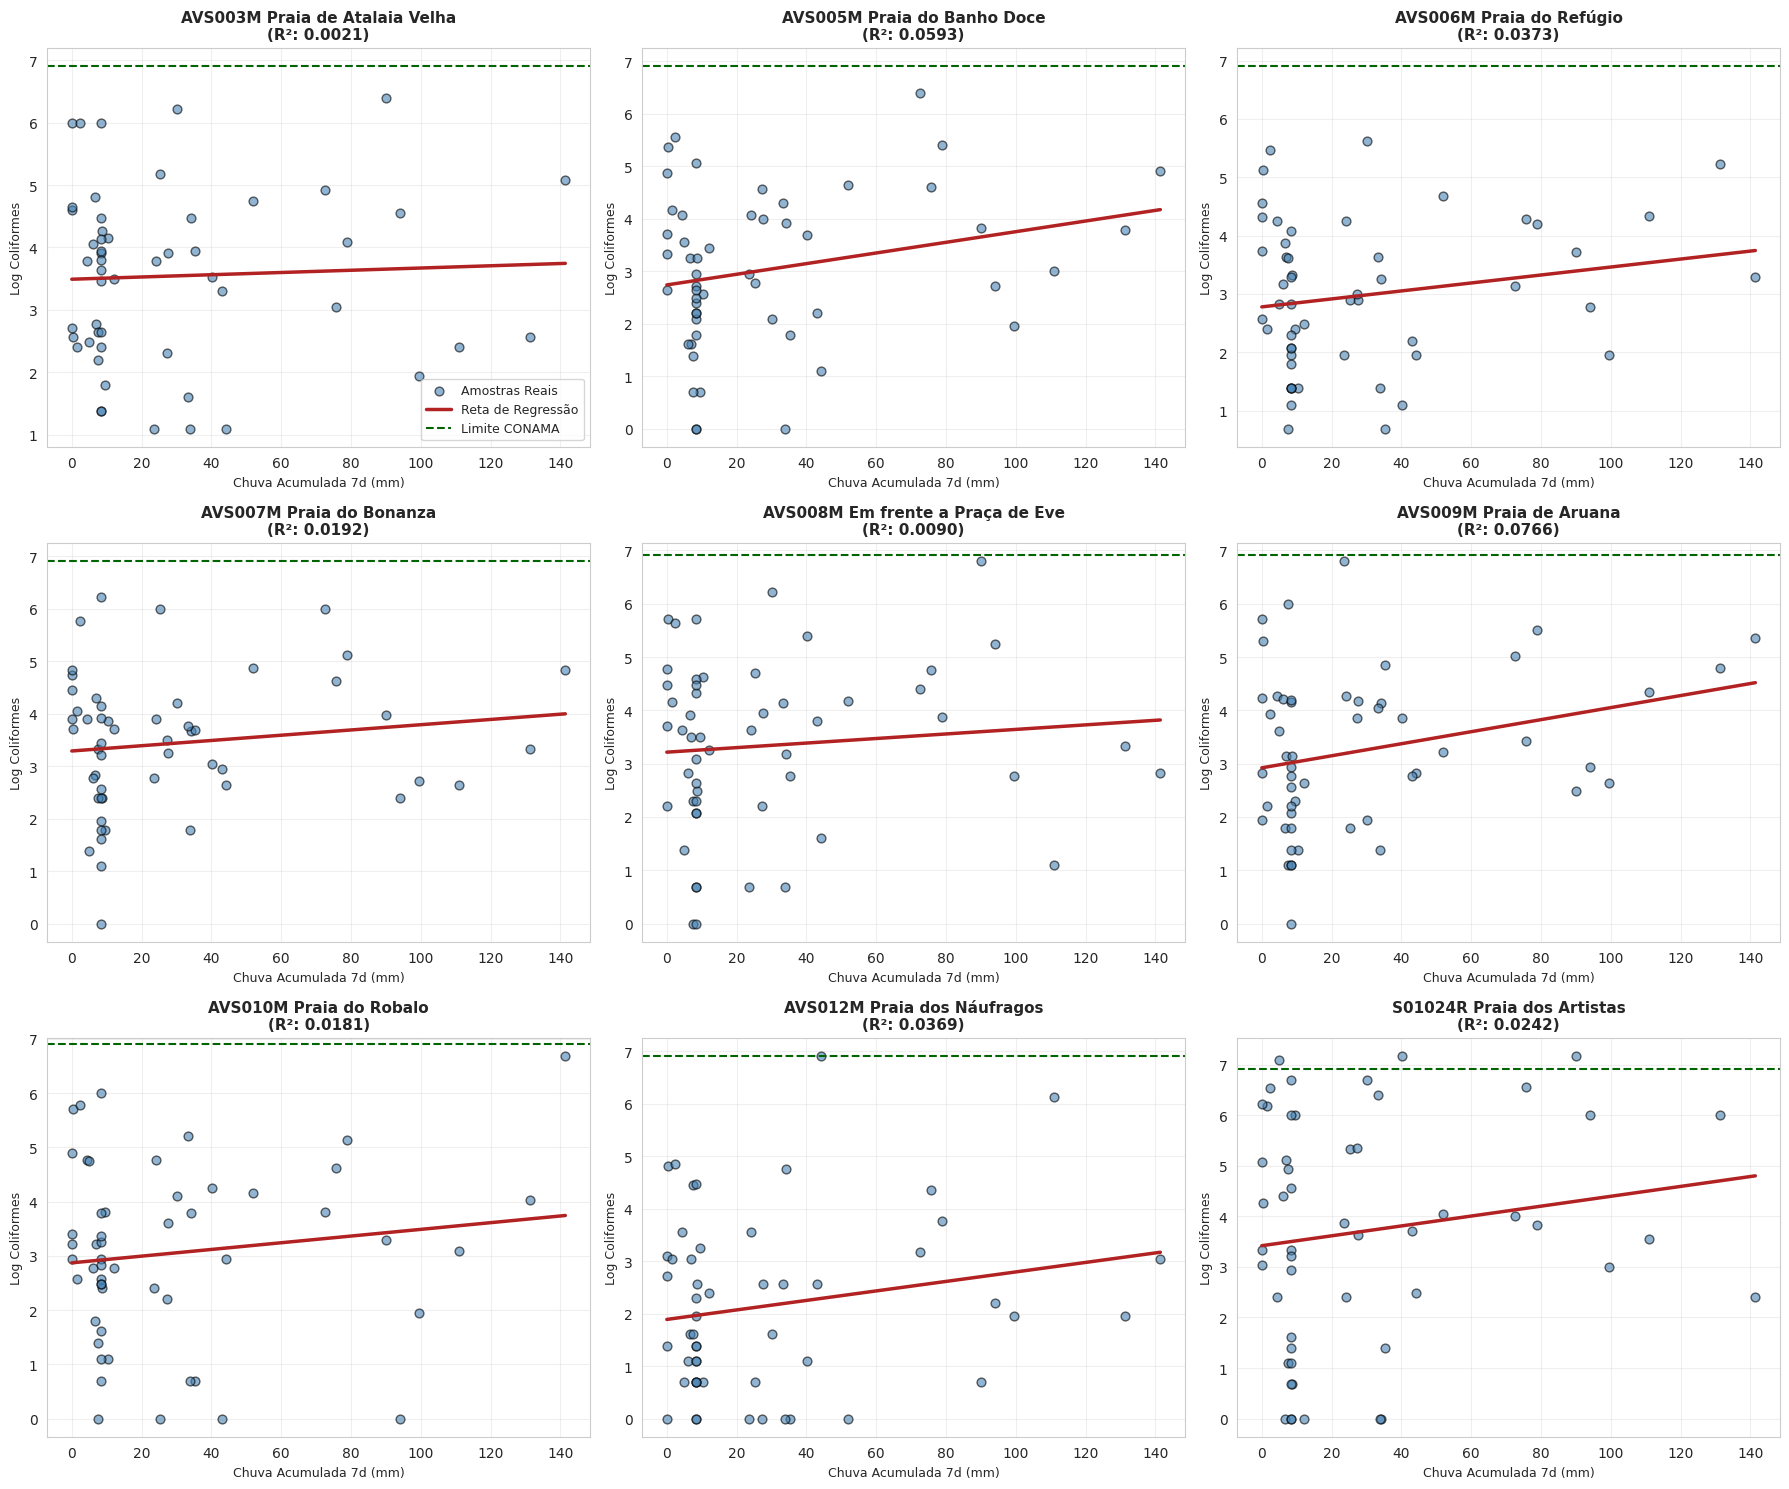

,Praia/Ponto,R²,Coef (Impacto Chuva)
5,AVS009M Praia de Aruana,0.0766,0.0113
1,AVS005M Praia do Banho Doce,0.0593,0.0101
2,AVS006M Praia do Refúgio,0.0373,0.0068
7,AVS012M Praia dos Náufragos,0.0369,0.0090
8,S01024R Praia dos Artistas,0.0242,0.0098
3,AVS007M Praia do Bonanza,0.0192,0.0050
6,AVS010M Praia do Robalo,0.0181,0.0062
4,AVS008M Em frente a Praça de Eve,0.0090,0.0043
0,AVS003M Praia de Atalaia Velha,0.0021,0.0018


In [ ]:
print("--- PROCESSANDO REGRESSÃO LINEAR SIMPLES E GERANDO GRÁFICOS ---")

resultados_simples = []
X_simples = df_final[['Prec_7d']].values

# Configuração do grid de gráficos (3 linhas x 3 colunas para cobrir as 9 praias)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

limiar_conama_log = np.log1p(1000)

for i, praia in enumerate(colunas_praias):
    # Filtragem de nulos localizados para garantir consistência por ponto
    df_praia = df_final[['Prec_7d', f'Log_{praia}']].dropna()
    X_p = df_praia[['Prec_7d']].values
    y_p = df_praia[f'Log_{praia}'].values

    # Ajuste do modelo linear simples
    mod = LinearRegression().fit(X_p, y_p)
    y_pred = mod.predict(X_p)

    r2 = r2_score(y_p, y_pred)
    coef = mod.coef_[0]

    # Tratamento estético do nome do ponto
    nome_curto = praia.split('-')[0].strip() + " " + praia.split('–')[0].split('-')[-1].strip()
    nome_curto = nome_curto[:32]

    resultados_simples.append({
        'Praia/Ponto': nome_curto,
        'R²': round(r2, 4),
        'Coef (Impacto Chuva)': round(coef, 4)
    })

    # Construção do gráfico individual no subplot correspondente
    ax = axes[i]
    ax.scatter(X_p, y_p, alpha=0.6, color='steelblue', edgecolor='k', s=40, label='Amostras Reais')

    # Ordenação dos vetores para plotagem fluida da linha contínua
    ordem = np.argsort(X_p.flatten())
    ax.plot(X_p[ordem], y_pred[ordem], color='firebrick', linewidth=2.5, label='Reta de Regressão')

    # Demarcação do limite regulatório do CONAMA
    ax.axhline(y=limiar_conama_log, color='darkgreen', linestyle='--', linewidth=1.5, label='Limite CONAMA')

    ax.set_title(f"{nome_curto}\n(R²: {r2:.4f})", fontsize=11, weight='bold')
    ax.set_xlabel('Chuva Acumulada 7d (mm)', fontsize=9)
    ax.set_ylabel('Log Coliformes', fontsize=9)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='best', fontsize=9)

# Remoção de eixos sobressalentes caso o número de praias mude
for j in range(len(colunas_praias), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Exibição da tabela consolidada ordenando pelo R²
df_resultados_simples = pd.DataFrame(resultados_simples).sort_values(by='R²', ascending=False)
display(df_resultados_simples)

### 3.1 Verificação de Multicolinearidade (Matriz de Correlação)

Antes de avançarmos para a Regressão Múltipla, precisamos verificar a correlação entre as nossas variáveis independentes (meteorológicas). Se duas variáveis forem altamente correlacionadas (ex: $> 0.8$), elas explicam a mesma variância no modelo, o que pode desestabilizar os coeficientes da regressão (fenômeno da multicolinearidade).

--- MATRIZ DE CORRELAÇÃO (VARIÁVEIS INDEPENDENTES) ---


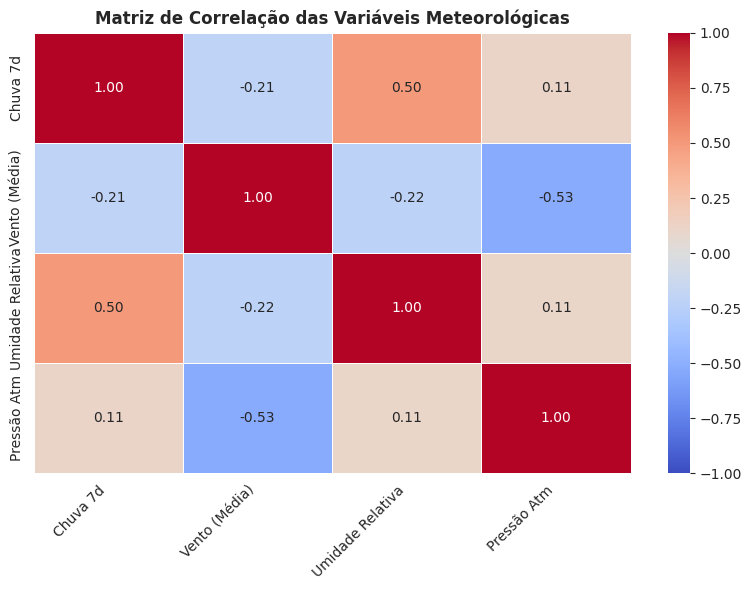

Interpretação: Correlações moderadas a baixas indicam que as variáveis trazem informações independentes úteis para o modelo múltiplo. Correlações muito altas (ex: Umidade vs Chuva) são esperadas, mas devem ser monitoradas para evitar overfitting nos coeficientes.


In [ ]:
print("--- MATRIZ DE CORRELAÇÃO (VARIÁVEIS INDEPENDENTES) ---")

features_clima = [
    'Prec_7d',
    'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)',
    'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)',
    'PRESSAO ATMOSFERICA MEDIA DIARIA (AUT)(mB)'
]

# Filtrar apenas as colunas de clima e remover nulos
df_clima_corr = df_final[features_clima].dropna()

# Renomear para facilitar a leitura no gráfico
nomes_curtos = ['Chuva 7d', 'Vento (Média)', 'Umidade Relativa', 'Pressão Atm']
df_clima_corr.columns = nomes_curtos

# Calcular correlação de Pearson
matriz_corr = df_clima_corr.corr()

# Plotar Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Meteorológicas', fontsize=12, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Interpretação: Correlações moderadas a baixas indicam que as variáveis trazem informações independentes úteis para o modelo múltiplo. Correlações muito altas (ex: Umidade vs Chuva) são esperadas, mas devem ser monitoradas para evitar overfitting nos coeficientes.")

## 4. Regressão Linear Múltipla por Praia

A dinâmica costeira responde a interações multivariadas. Incorporamos ao modelo o vetor de variáveis mecânicas e termodinâmicas (vento, umidade e pressão atmosférica). Abaixo, avaliamos o modelo múltiplo calculando o **R-quadrado ($R^2$)**.

Para inspecionar visualmente a qualidade do ajuste linear em um espaço multidimensional, os gráficos confrontam os **Valores Preditos** pelo modelo contra os **Valores Reais (Observados)**. A proximidade dos pontos em relação à linha de tendência demonstra a capacidade preditiva do modelo para cada ponto da orla.

--- PROCESSANDO REGRESSÃO MÚLTIPLA E GERANDO GRÁFICOS COM COEFICIENTES ---


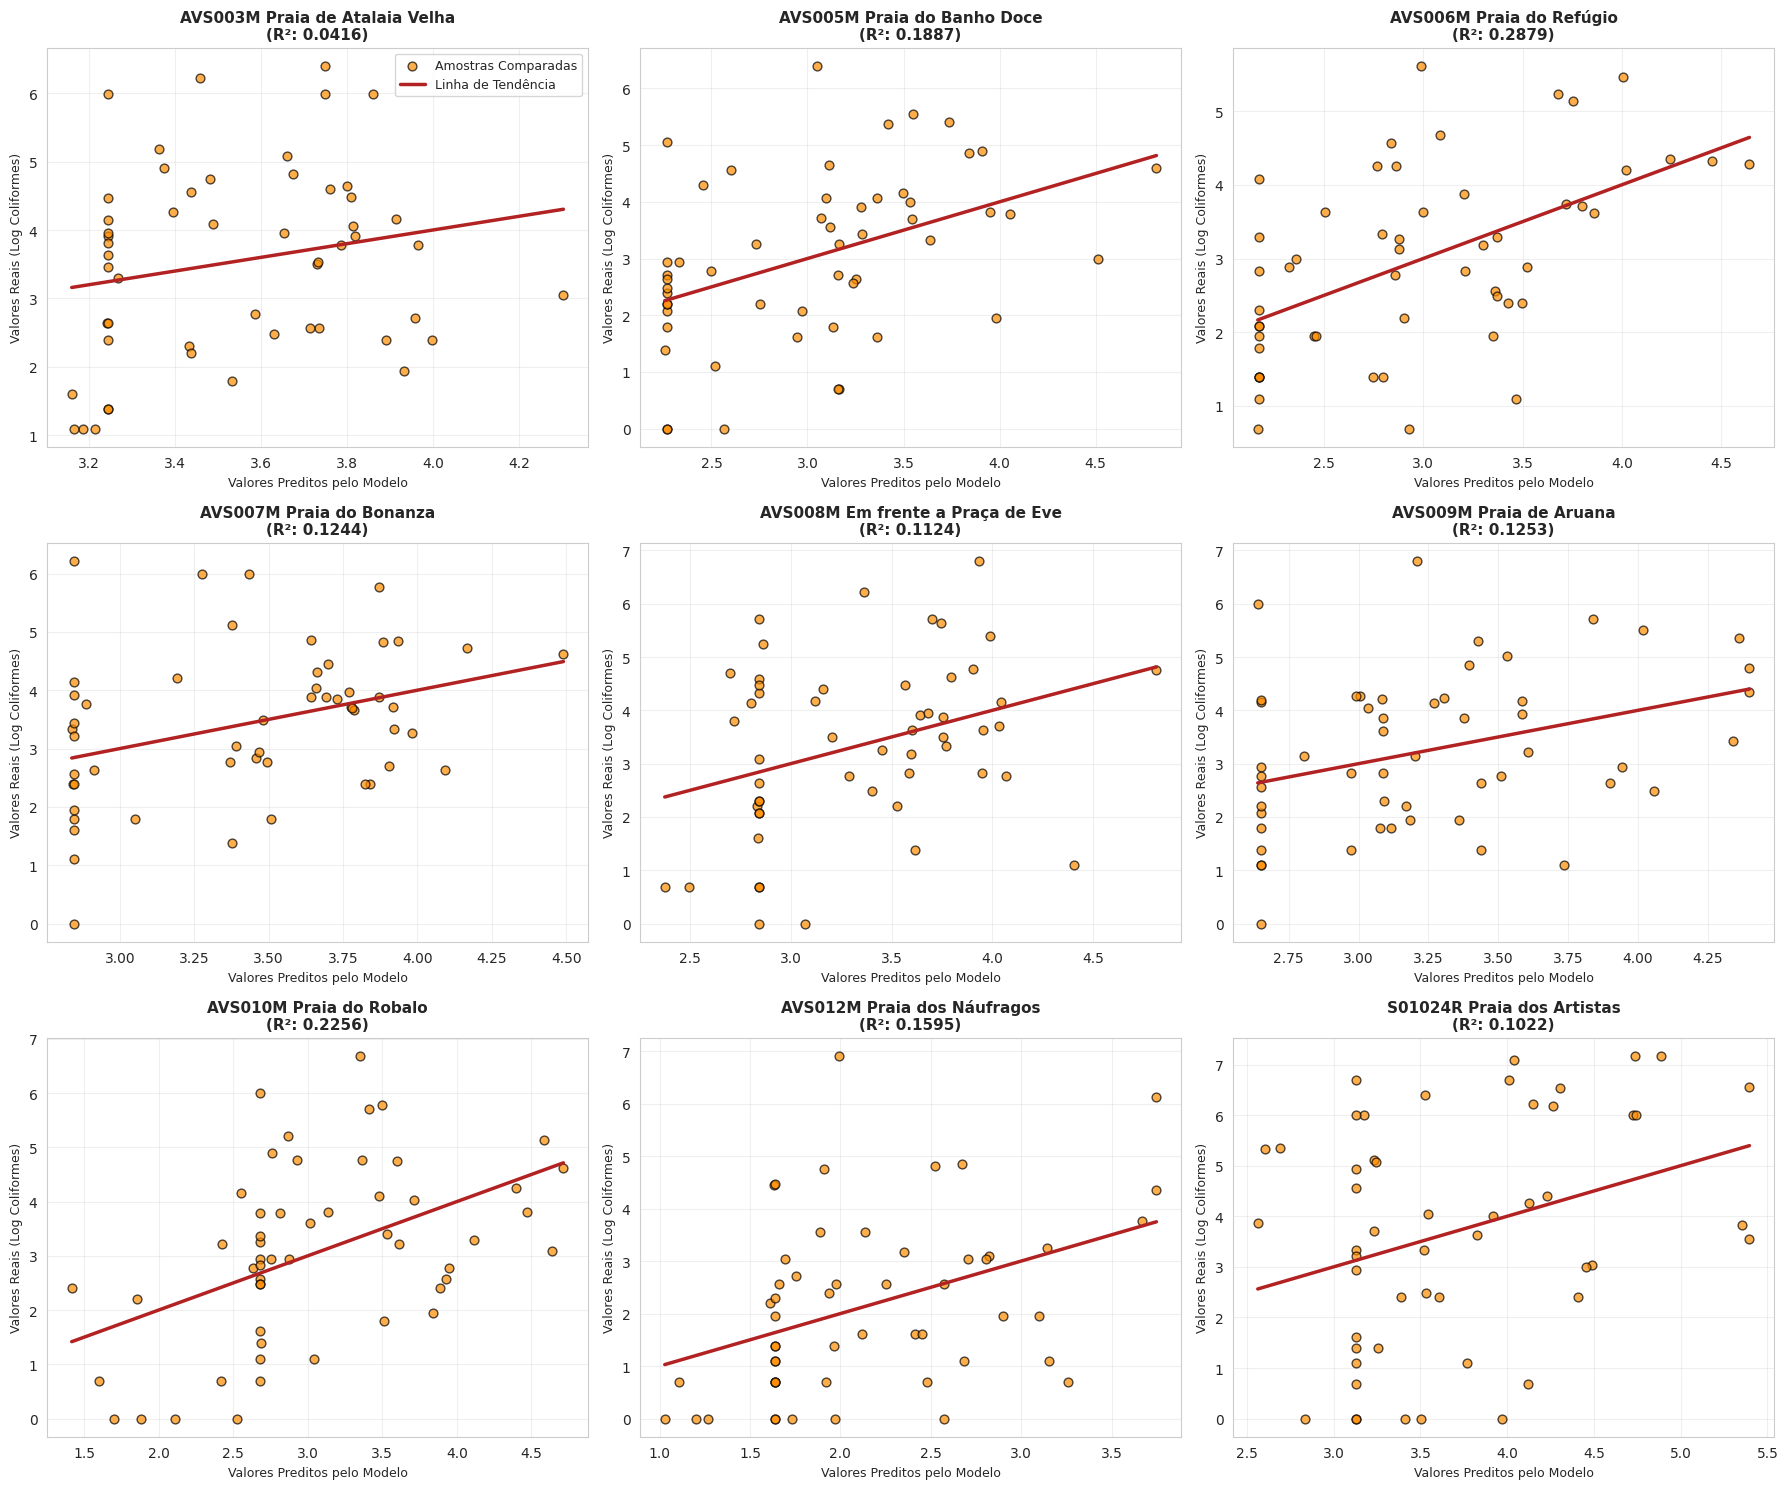

,Praia/Ponto,R²,Coef Chuva (7d),Coef Vento,Coef Umidade,Coef Pressão
2,AVS006M Praia do Refúgio,0.2879,0.0062,0.5703,0.0533,-0.1149
6,AVS010M Praia do Robalo,0.2256,-0.0024,-0.2082,0.1297,-0.1842
9,MÉDIA GLOBAL DA ORLA (SECUNDÁRIA),0.2020,0.0060,0.1828,0.0577,-0.0892
1,AVS005M Praia do Banho Doce,0.1887,0.0103,0.1904,0.0281,-0.1592
7,AVS012M Praia dos Náufragos,0.1595,0.0033,0.0948,0.1004,-0.1298
5,AVS009M Praia de Aruana,0.1253,0.0126,0.4026,0.0080,-0.0337
3,AVS007M Praia do Bonanza,0.1244,0.0087,0.2706,-0.0240,-0.0949
4,AVS008M Em frente a Praça de Eve,0.1124,0.0026,-0.0995,0.0403,-0.1828
8,S01024R Praia dos Artistas,0.1022,0.0038,0.1623,0.1065,-0.1298
0,AVS003M Praia de Atalaia Velha,0.0416,0.0025,-0.0394,0.0004,-0.1013


In [ ]:
print("--- PROCESSANDO REGRESSÃO MÚLTIPLA E GERANDO GRÁFICOS COM COEFICIENTES ---")

features_completas = [
    'Prec_7d',
    'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)',
    'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)',
    'PRESSAO ATMOSFERICA MEDIA DIARIA (AUT)(mB)'
]

resultados_multiplos = []

# Configuração do grid de gráficos (3 linhas x 3 colunas para cobrir as 9 praias)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, praia in enumerate(colunas_praias):
    df_reg = df_final.dropna(subset=features_completas + [f'Log_{praia}'])
    X_comp = df_reg[features_completas].values
    y_comp = df_reg[f'Log_{praia}'].values

    # Ajuste do modelo múltiplo
    mod_multi = LinearRegression().fit(X_comp, y_comp)
    y_pred_m = mod_multi.predict(X_comp)

    # Cálculo normal do R-quadrado
    r2_m = r2_score(y_comp, y_pred_m)

    # Extração e mapeamento dos coeficientes individuais do array
    coef_chuva = mod_multi.coef_[0]
    coef_vento = mod_multi.coef_[1]
    coef_umidade = mod_multi.coef_[2]
    coef_pressao = mod_multi.coef_[3]

    nome_curto = praia.split('-')[0].strip() + " " + praia.split('–')[0].split('-')[-1].strip()
    nome_curto = nome_curto[:32]

    # Inclusão dos coeficientes discriminados no dicionário de resultados
    resultados_multiplos.append({
        'Praia/Ponto': nome_curto,
        'R²': round(r2_m, 4),
        'Coef Chuva (7d)': round(coef_chuva, 4),
        'Coef Vento': round(coef_vento, 4),
        'Coef Umidade': round(coef_umidade, 4),
        'Coef Pressão': round(coef_pressao, 4)
    })

    # Gráfico de dispersão: Predito vs Real
    ax = axes[i]
    ax.scatter(y_pred_m, y_comp, alpha=0.7, color='darkorange', edgecolor='k', s=40, label='Amostras Comparadas')

    # Plotagem da reta linear de ajuste do modelo multivariado
    if len(y_pred_m) > 1:
        ajuste_reta = LinearRegression().fit(y_pred_m.reshape(-1, 1), y_comp)
        x_linha = np.linspace(y_pred_m.min(), y_pred_m.max(), 100).reshape(-1, 1)
        y_linha = ajuste_reta.predict(x_linha)
        ax.plot(x_linha, y_linha, color='firebrick', linewidth=2.5, label='Linha de Tendência')

    ax.set_title(f"{nome_curto}\n(R²: {r2_m:.4f})", fontsize=11, weight='bold')
    ax.set_xlabel('Valores Preditos pelo Modelo', fontsize=9)
    ax.set_ylabel('Valores Reais (Log Coliformes)', fontsize=9)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='best', fontsize=9)

# Remoção de subplots ociosos se houver
for j in range(len(colunas_praias), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Inclusão da análise secundária agregada (Média Global) com seus respectivos coeficientes
df_reg_media = df_final.dropna(subset=features_completas + ['Log_Media_Coliformes'])
X_media = df_reg_media[features_completas].values
y_media = df_reg_media['Log_Media_Coliformes'].values

mod_media = LinearRegression().fit(X_media, y_media)
r2_m_media = r2_score(y_media, mod_media.predict(X_media))

resultados_multiplos.append({
    'Praia/Ponto': 'MÉDIA GLOBAL DA ORLA (SECUNDÁRIA)',
    'R²': round(r2_m_media, 4),
    'Coef Chuva (7d)': round(mod_media.coef_[0], 4),
    'Coef Vento': round(mod_media.coef_[1], 4),
    'Coef Umidade': round(mod_media.coef_[2], 4),
    'Coef Pressão': round(mod_media.coef_[3], 4)
})

# Consolidação e exibição da tabela final ordenada por R²
df_resultados_multiplos = pd.DataFrame(resultados_multiplos).sort_values(by='R²', ascending=False)
display(df_resultados_multiplos)

## 5. Validação dos Modelos: Overfitting e Underfitting em Machine Learning

Após a formulação inicial dos modelos de regressão, é fundamental atestar a sua real capacidade preditiva. Em Machine Learning, avaliar a precisão de um algoritmo usando os mesmos dados em que ele "aprendeu" gera uma perigosa ilusão de competência.

Para corrigir isso, introduzimos a validação cruzada simples (divisão entre dados de Treinamento e Teste). Isso nos permite diagnosticar três cenários clássicos:
* **Underfitting (Subajuste):** O modelo é simples demais e não captura o padrão dos dados.
* **Good Fit (Ajuste Ideal):** O modelo encontra o equilíbrio e generaliza bem para dados inéditos.
* **Overfitting (Sobreajuste):** O modelo é complexo demais, decora o ruído da base de treinamento, mas falha drasticamente na vida real.

### 5.1 Comparando Todos os Modelos de Erro

Para visualizar esses comportamentos, testamos três graus de complexidade polinomial na relação entre a precipitação de 7 dias e a balneabilidade agregada da orla.

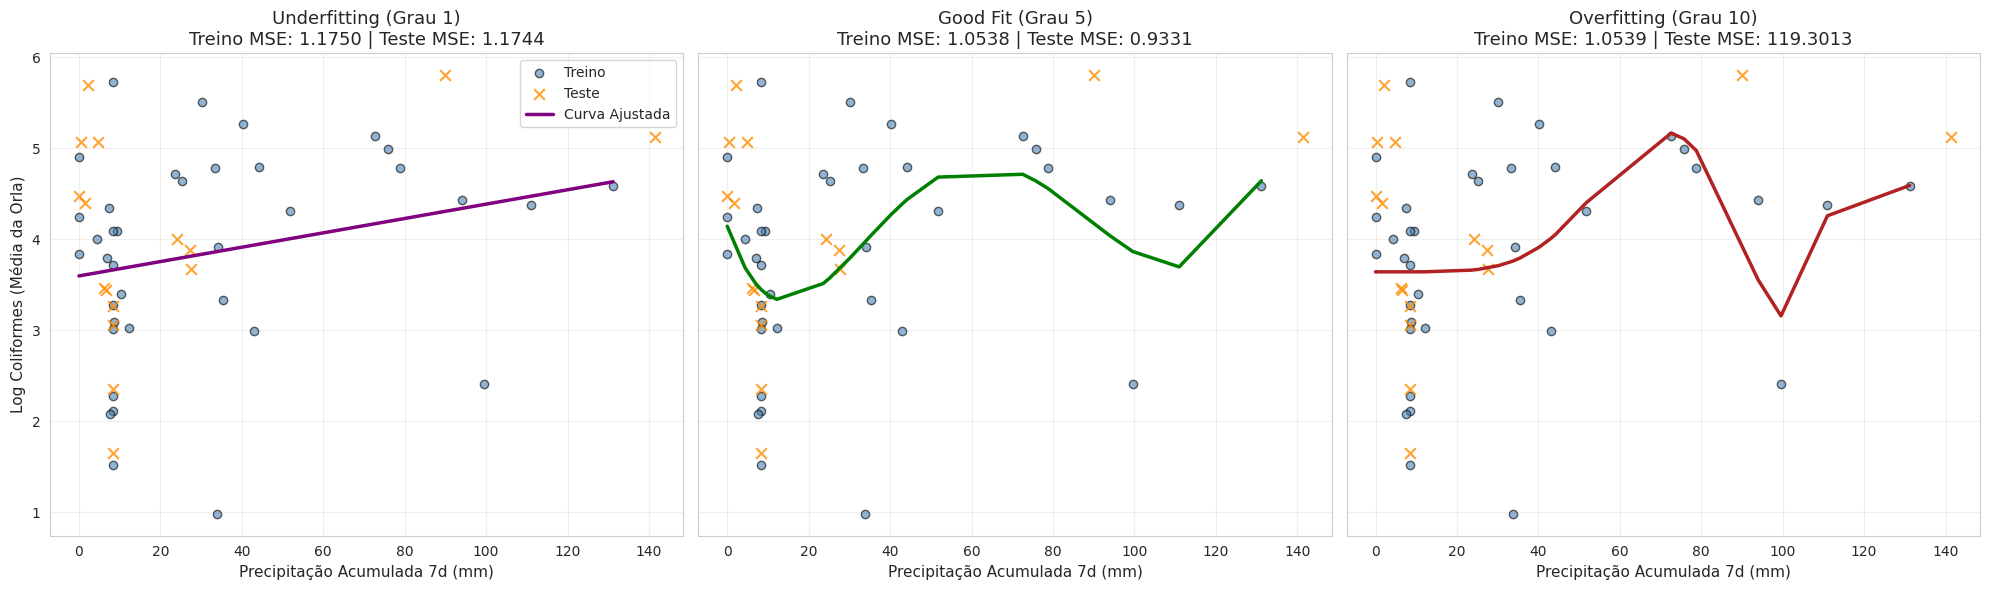

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Preparação dos dados usando a Média Global da Orla contra a Precipitação de 7 dias
df_comp = df_final[['Prec_7d', 'Log_Media_Coliformes']].dropna()
X_c = df_comp[['Prec_7d']].values
y_c = df_comp['Log_Media_Coliformes'].values

# Divisão rigorosa em Treino (70%) e Teste (30%)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.3, random_state=42)

# Ordenação para o plot contínuo da linha
order_train = np.argsort(X_train_c.flatten())
X_train_plot = X_train_c[order_train]

# Definição dos três graus testados na etapa anterior
graus_analise = [1, 5, 10]
titulos = ['Underfitting (Grau 1)', 'Good Fit (Grau 5)', 'Overfitting (Grau 10)']
cores_linha = ['purple', 'green', 'firebrick']

# Configuração do Gráfico Lado a Lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, grau in enumerate(graus_analise):
    # Criação e treinamento do modelo polinomial
    modelo = make_pipeline(PolynomialFeatures(grau), LinearRegression())
    modelo.fit(X_train_c, y_train_c)

    # Previsões para traçar a linha (usando os pontos ordenados)
    y_plot_pred = modelo.predict(X_train_plot)

    # Previsões para calcular os erros
    y_pred_train = modelo.predict(X_train_c)
    y_pred_test = modelo.predict(X_test_c)

    # Cálculo das métricas
    mse_train = mean_squared_error(y_train_c, y_pred_train)
    mse_test = mean_squared_error(y_test_c, y_pred_test)

    # Plotagem
    ax = axes[i]
    ax.scatter(X_train_c, y_train_c, color='steelblue', alpha=0.6, edgecolor='k', label='Treino')
    ax.scatter(X_test_c, y_test_c, color='darkorange', alpha=0.8, edgecolor='k', marker='x', s=60, label='Teste')
    ax.plot(X_train_plot, y_plot_pred, color=cores_linha[i], linewidth=2.5, label='Curva Ajustada')

    # Estética do Subplot
    ax.set_title(f"{titulos[i]}\nTreino MSE: {mse_train:.4f} | Teste MSE: {mse_test:.4f}", fontsize=13)
    ax.set_xlabel('Precipitação Acumulada 7d (mm)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Log Coliformes (Média da Orla)', fontsize=11)
        ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Análise do Desempenho do Modelo

A métrica principal de diagnóstico gerada a partir dos testes é a **Razão de Overfitting** (Erro de Teste / Erro de Treino). O painel abaixo detalha o comportamento dos erros em função da complexidade.

In [ ]:
# 9. Análise do Desempenho do Modelo
# Iteração Iterando a Complexidade (Grau 1 ao 10) para extrair o Trade-off
graus = range(1, 11)
train_errors = []
test_errors = []
resultados_tradeoff = []

# Guardando métricas específicas para o print final
metricas_resumo = {}

for grau in graus:
    modelo_poly = make_pipeline(PolynomialFeatures(grau), LinearRegression())
    modelo_poly.fit(X_train_c, y_train_c)

    y_pred_train = modelo_poly.predict(X_train_c)
    y_pred_test = modelo_poly.predict(X_test_c)

    mse_train = mean_squared_error(y_train_c, y_pred_train)
    mse_test = mean_squared_error(y_test_c, y_pred_test)

    train_errors.append(mse_train)
    test_errors.append(mse_test)

    ratio = mse_test / mse_train if mse_train > 0 else np.nan

    resultados_tradeoff.append({
        'Grau': grau,
        'MSE Treino': round(mse_train, 4),
        'MSE Teste': round(mse_test, 4),
        'Razão de Overfitting': round(ratio, 2)
    })

    # Armazenando os dados dos graus selecionados para o Resumo
    if grau in [1, 5, 10]:
        metricas_resumo[grau] = (mse_train, mse_test, ratio)

# Output text idêntico ao 005_Overfitting_and_Underfitting.py
print("Detailed Analysis of Model Performance:\n")
print(f"{'Model Type':<18} {'Training MSE':<15} {'Test MSE':<15} {'Overfitting Ratio'}")
print("-" * 65)

# Acessando Grau 1 (Underfitting), Grau 5 (Good Fit) e Grau 10 (Overfitting)
tr_u, ts_u, r_u = metricas_resumo[1]
print(f"{'Underfitting':<18} {tr_u:>10.2f} {ts_u:>15.2f} {r_u:>15.2f}")

tr_g, ts_g, r_g = metricas_resumo[5]
print(f"{'Good Fit':<18} {tr_g:>10.2f} {ts_g:>15.2f} {r_g:>15.2f}")

tr_o, ts_o, r_o = metricas_resumo[10]
print(f"{'Overfitting':<18} {tr_o:>10.2f} {ts_o:>15.2f} {r_o:>15.2f}")

print("\nObservations:")
print("1. Underfitting: The model is too simple, leading to higher errors on both training and test data.")
print("2. Good Fit: The degree 5 polynomial captures the true trend well, with optimal errors on test data.")
print("3. Overfitting: The high-degree polynomial (degree 10) fits the noise in the training data more closely,")
print("   resulting in a lower training error but a noticeably higher test error.")
print("A higher overfitting ratio (Test MSE / Training MSE) indicates poorer generalization.\n")

# Exibição Numérica Completa
print("--- EVOLUÇÃO DO ERRO POR COMPLEXIDADE ---")
df_tradeoff = pd.DataFrame(resultados_tradeoff)
display(df_tradeoff)

Detailed Analysis of Model Performance:

Model Type         Training MSE    Test MSE        Overfitting Ratio
-----------------------------------------------------------------
Underfitting             1.18            1.17            1.00
Good Fit                 1.05            0.93            0.89
Overfitting              1.05          119.30          113.20

Observations:
1. Underfitting: The model is too simple, leading to higher errors on both training and test data.
2. Good Fit: The degree 5 polynomial captures the true trend well, with optimal errors on test data.
3. Overfitting: The high-degree polynomial (degree 10) fits the noise in the training data more closely,
   resulting in a lower training error but a noticeably higher test error.
A higher overfitting ratio (Test MSE / Training MSE) indicates poorer generalization.

--- EVOLUÇÃO DO ERRO POR COMPLEXIDADE ---


,Grau,MSE Treino,MSE Teste,Razão de Overfitting
0,1,1.1750,1.1744,1.00
1,2,1.1595,1.2944,1.12
2,3,1.1587,1.2880,1.11
3,4,1.0562,1.0816,1.02
4,5,1.0538,0.9331,0.89
5,6,1.0504,1.4537,1.38
6,7,1.0745,6.9055,6.43
7,8,1.0318,96.7783,93.80
8,9,1.0251,484.6281,472.76
9,10,1.0539,119.3013,113.20


### 5.3 Visualizando o Bias-Variance Tradeoff

O gráfico abaixo materializa o limite de aprendizagem do modelo. O ponto onde a curva de Teste (vermelha) se descola da curva de Treino (azul) indica o exato instante em que o algoritmo deixa de compreender o fenômeno ambiental e começa a se autoiludir com a base de dados.

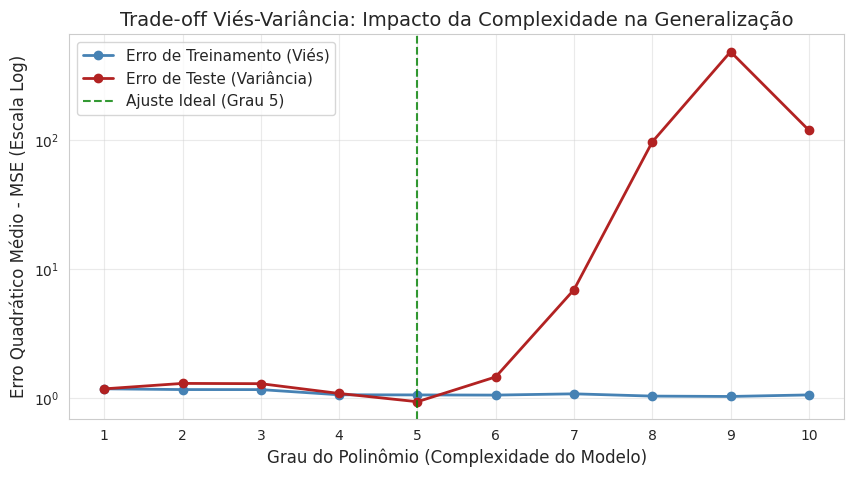


Optimal polynomial degree for this dataset: 5

Bias-Variance Tradeoff Explained:
1. As model complexity increases, training error consistently decreases
2. Test error initially decreases, then increases as overfitting begins
3. The optimal model has the right balance between bias and variance
4. Simpler models have high bias (underfitting)
5. More complex models have high variance (overfitting)


In [ ]:
# 10. Visualização do Bias-Variance Tradeoff
plt.figure(figsize=(10, 5))
plt.semilogy(graus, train_errors, 'o-', color='steelblue', linewidth=2, label='Erro de Treinamento (Viés)')
plt.semilogy(graus, test_errors, 'o-', color='firebrick', linewidth=2, label='Erro de Teste (Variância)')

# Identificação do Ponto Ótimo
grau_otimo = graus[np.argmin(test_errors)]
plt.axvline(x=grau_otimo, color='green', linestyle='--', alpha=0.8,
            label=f'Ajuste Ideal (Grau {grau_otimo})')

plt.title('Trade-off Viés-Variância: Impacto da Complexidade na Generalização', fontsize=14)
plt.xlabel('Grau do Polinômio (Complexidade do Modelo)', fontsize=12)
plt.ylabel('Erro Quadrático Médio - MSE (Escala Log)', fontsize=12)
plt.xticks(graus)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.show()

# Output text idêntico ao 005_Overfitting_and_Underfitting.py
print(f"\nOptimal polynomial degree for this dataset: {grau_otimo}\n")
print("Bias-Variance Tradeoff Explained:")
print("1. As model complexity increases, training error consistently decreases")
print("2. Test error initially decreases, then increases as overfitting begins")
print("3. The optimal model has the right balance between bias and variance")
print("4. Simpler models have high bias (underfitting)")
print("5. More complex models have high variance (overfitting)")

## 6. Aplicação: Regressão Múltipla com Validação de Overfitting

Com a metodologia fundamentada, reprocessamos a **Regressão Múltipla** para cada ponto da orla utilizando a separação obrigatória de `Train/Test Split`.

Os gráficos abaixo exibem o desempenho isolado de cada praia (Valores Preditos vs. Valores Reais), destacando quais pontos sofrem de contaminação meteorológica real e quais sofrem de anomalias perenes desvinculadas do clima (identificáveis pela Razão de Overfitting alta ou R² negativo no teste).

--- REGRESSÃO MÚLTIPLA COM VALIDAÇÃO (TRAIN/TEST SPLIT) E GRÁFICOS ---


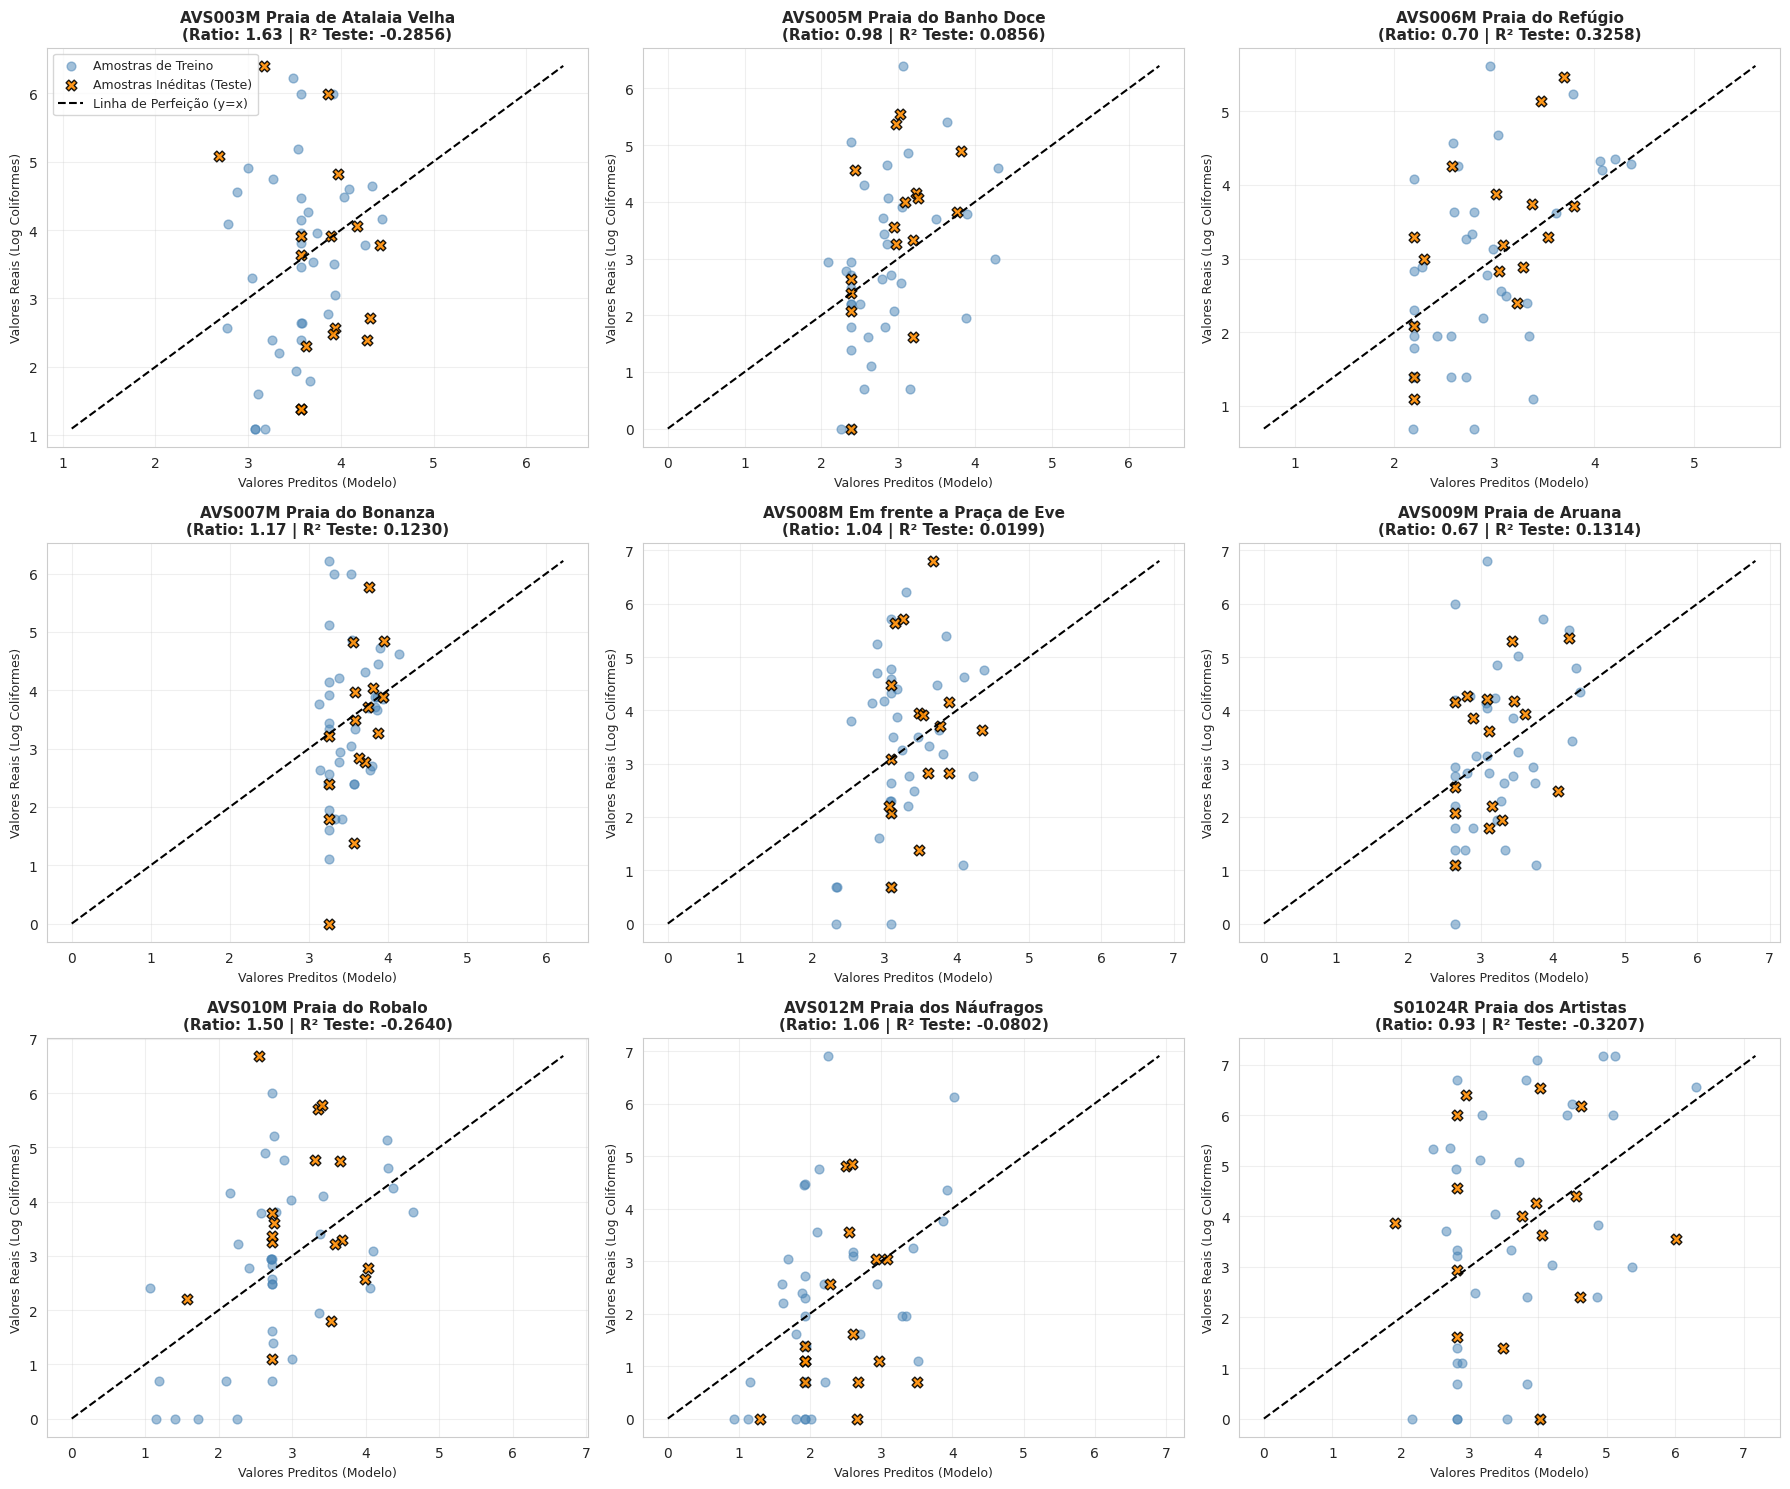

,Praia/Ponto,MSE Treino,MSE Teste,Ratio (Overfitting),R² (Teste)
0,AVS003M Praia de Atalaia Velha,1.6549,2.7039,1.63,-0.2856
6,AVS010M Praia do Robalo,1.8405,2.7665,1.50,-0.2640
3,AVS007M Praia do Bonanza,1.4283,1.6711,1.17,0.1230
7,AVS012M Praia dos Náufragos,2.3503,2.4886,1.06,-0.0802
4,AVS008M Em frente a Praça de Eve,2.3035,2.4025,1.04,0.0199
1,AVS005M Praia do Banho Doce,1.8455,1.8128,0.98,0.0856
8,S01024R Praia dos Artistas,4.7823,4.4326,0.93,-0.3207
2,AVS006M Praia do Refúgio,1.2532,0.8772,0.70,0.3258
5,AVS009M Praia de Aruana,2.0356,1.3664,0.67,0.1314


In [ ]:
print("--- REGRESSÃO MÚLTIPLA COM VALIDAÇÃO (TRAIN/TEST SPLIT) E GRÁFICOS ---")

features_completas = [
    'Prec_7d',
    'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)',
    'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)',
    'PRESSAO ATMOSFERICA MEDIA DIARIA (AUT)(mB)'
]

resultados_validacao = []
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, praia in enumerate(colunas_praias):
    df_reg = df_final.dropna(subset=features_completas + [f'Log_{praia}'])
    X_comp = df_reg[features_completas].values
    y_comp = df_reg[f'Log_{praia}'].values

    # 1. Train/Test Split (70/30)
    X_train, X_test, y_train, y_test = train_test_split(X_comp, y_comp, test_size=0.3, random_state=42)

    # 2. Treinamento na base segura
    mod_multi = LinearRegression().fit(X_train, y_train)

    # 3. Previsões
    y_pred_train = mod_multi.predict(X_train)
    y_pred_test = mod_multi.predict(X_test)

    # 4. Cálculo de Métricas
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    overfitting_ratio = mse_test / mse_train if mse_train > 0 else np.nan

    nome_curto = praia.split('-')[0].strip() + " " + praia.split('–')[0].split('-')[-1].strip()
    nome_curto = nome_curto[:32]

    resultados_validacao.append({
        'Praia/Ponto': nome_curto,
        'MSE Treino': round(mse_train, 4),
        'MSE Teste': round(mse_test, 4),
        'Ratio (Overfitting)': round(overfitting_ratio, 2),
        'R² (Teste)': round(r2_test, 4)
    })

    # Gráficos (Predito vs Real) visualizando o comportamento no Treino e no Teste
    ax = axes[i]
    ax.scatter(y_pred_train, y_train, alpha=0.5, color='steelblue', label='Amostras de Treino', s=40)
    ax.scatter(y_pred_test, y_test, alpha=0.9, color='darkorange', edgecolor='k', marker='X', s=60, label='Amostras Inéditas (Teste)')

    # Linha Ideal (Onde Predito = Real)
    min_val = min(min(y_train), min(y_test), min(y_pred_train), min(y_pred_test))
    max_val = max(max(y_train), max(y_test), max(y_pred_train), max(y_pred_test))
    ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5, label='Linha de Perfeição (y=x)')

    ax.set_title(f"{nome_curto}\n(Ratio: {overfitting_ratio:.2f} | R² Teste: {r2_test:.4f})", fontsize=11, weight='bold')
    ax.set_xlabel('Valores Preditos (Modelo)', fontsize=9)
    ax.set_ylabel('Valores Reais (Log Coliformes)', fontsize=9)
    ax.grid(True, alpha=0.3)
    if i == 0: ax.legend(loc='best', fontsize=9)

# Limpeza de quadros não utilizados
for j in range(len(colunas_praias), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Consolidação da Tabela Final
df_resultados_validacao = pd.DataFrame(resultados_validacao).sort_values(by='Ratio (Overfitting)', ascending=False)
display(df_resultados_validacao)

### 6.1 Análise de Resíduos: O Diagnóstico Definitivo do Modelo

Como visto nos fundamentos matemáticos da regressão, o "resíduo" é a diferença entre o valor observado e o previsto. Para que o nosso modelo linear seja estatisticamente válido, os resíduos devem apresentar **homocedasticidade** (variância constante) e estar distribuídos aleatoriamente ao redor do zero. O gráfico abaixo valida se a nossa transformação logarítmica inicial cumpriu esse papel.

--- ANÁLISE DE RESÍDUOS (MÉDIA GLOBAL DA ORLA) ---


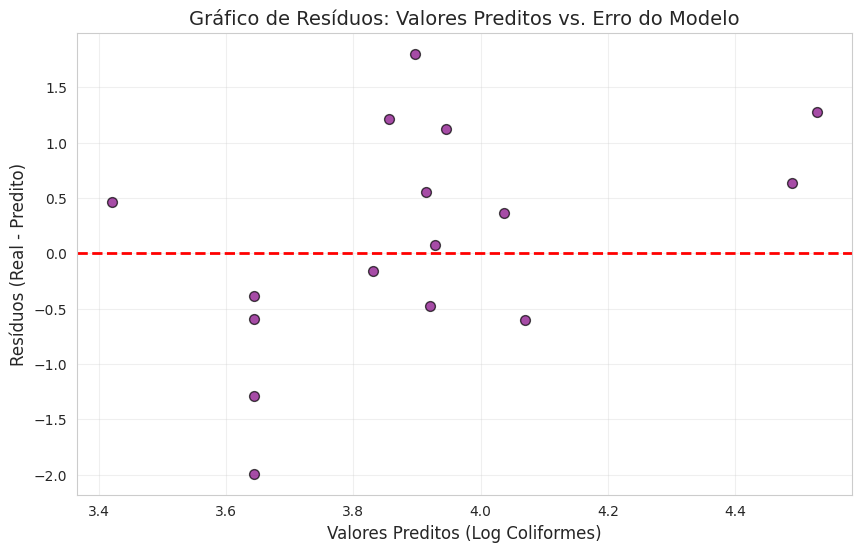

Interpretação: Se os pontos estiverem dispersos aleatoriamente em torno da linha vermelha (zero), sem formar um padrão de 'funil' ou 'curva', os pressupostos da regressão (linearidade e homocedasticidade) foram atendidos com sucesso graças à nossa transformação logarítmica inicial.


In [ ]:
print("--- ANÁLISE DE RESÍDUOS (MÉDIA GLOBAL DA ORLA) ---")

# Vamos usar os dados de treino e teste da Média Global
X_res = df_reg_media[features_completas].values
y_res = df_reg_media['Log_Media_Coliformes'].values

X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

mod_res = LinearRegression().fit(X_train_res, y_train_res)
y_pred_res = mod_res.predict(X_test_res)

# Cálculo dos Resíduos
residuos = y_test_res - y_pred_res

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_res, residuos, color='purple', alpha=0.7, edgecolor='k', s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Gráfico de Resíduos: Valores Preditos vs. Erro do Modelo', fontsize=14)
plt.xlabel('Valores Preditos (Log Coliformes)', fontsize=12)
plt.ylabel('Resíduos (Real - Predito)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretação: Se os pontos estiverem dispersos aleatoriamente em torno da linha vermelha (zero), sem formar um padrão de 'funil' ou 'curva', os pressupostos da regressão (linearidade e homocedasticidade) foram atendidos com sucesso graças à nossa transformação logarítmica inicial.")

## 7. Conclusão Geral e Limitações do Estudo

A modelagem preditiva estruturada neste projeto revelou nuances fundamentais sobre a dinâmica hídrica e sanitária da orla de Aracaju no ano de 2025. Ao transitar de algoritmos lineares simples para a validação rigorosa de *Machine Learning* (Trade-off de Viés e Variância), o estudo consolida as seguintes evidências estatísticas e ambientais:

1. **O Clima não explica tudo (A Assinatura de cada Praia):** A regressão múltipla com validação cruzada comprovou que a orla não é homogênea. Pontos como a *Praia dos Artistas* (Coroa do Meio) e *Atalaia Velha* apresentaram forte distorção estatística (*Underfitting/Overfitting*). Isso atesta que a contaminação nesses locais independe de chuvas ou ventos, sendo governada por fatores perenes: a foz do Rio Sergipe, alta densidade de ocupação turística e prováveis passivos contínuos na rede de drenagem e esgoto.
2. **O Limite Preditivo da Chuva (Polinômio de Grau 5):** O carreamento de poluentes via escoamento superficial não segue uma reta perfeitamente proporcional. O modelo encontrou seu ajuste ideal em uma curva polinomial de Grau 5. Isso significa que a balneabilidade resiste até um certo volume de chuva acumulada, mas após um "pico de saturação" das galerias pluviais, a carga de coliformes despejada no mar cresce de forma logarítmica e acentuada.
3. **Robustez Estatística:** Ao aplicar a transformação logarítmica e separar os dados rigorosamente entre Treino e Teste, o projeto evitou o mascaramento de resultados. As métricas refletem o limite da realidade do litoral sergipano e oferecem um *baseline* algorítmico seguro para monitoramento.
4. **Limitações e Qualidade dos Dados:** A precisão preditiva do algoritmo foi severamente contida pela descontinuidade temporal nas bases brutas oficiais. As falhas de sensoriamento do INMET exigiram métodos de imputação matricial (como o *forward fill*), mascarando microclimas instantâneos. Simultaneamente, as lacunas de monitoramento da ADEMA reduziram a volumetria da amostra da orla. Essa escassez de dados restringe a capacidade algorítmica de mapear eventos extremos de contaminação com máxima exatidão, evidenciando que, para o avanço da modelagem ambiental preditiva no estado, são emergenciais os investimentos governamentais em telemetria contínua e integração automatizada de dados.

## 8. Aplicação Estratégica: Como a ADEMA pode utilizar este Modelo?

O valor de um *pipeline* de dados reside na sua aplicação prática. Os algoritmos desenvolvidos neste estudo podem ser internalizados pela Administração Estadual do Meio Ambiente (ADEMA) de Sergipe sob três eixos de atuação:

* **Sistemas de Alerta Prévio (Early Warning):** Integrando este algoritmo a uma API de previsão do tempo (INMET), a ADEMA pode cruzar a previsão de chuvas dos próximos 7 dias no modelo polinomial e emitir alertas de "Risco de Impropriedade" para a população antes mesmo da recolha laboratorial física.
* **Previsão Estatística na Ausência de Recolha:** Em semanas onde ocorram falhas logísticas, indisponibilidade de equipas ou quebra de equipamentos que impossibilitem a medição in loco, o modelo consegue calcular a **probabilidade estatística** exata de a água estar própria ou imprópria para banhos, servindo como uma salvaguarda para a saúde pública.
* **Fiscalização Direcionada:** Como o modelo identificou que as praias da Atalaia Velha e Artistas têm poluição independente do clima, a ADEMA pode direcionar equipas de fiscalização em tempo seco exclusivamente para essas regiões, focando na caça a ligações clandestinas de esgoto.

Abaixo, apresentamos a prova de conceito em código de como o modelo treinado funcionaria dentro do sistema de TI da ADEMA, abordando cenários de normalidade, impossibilidade de medição e níveis críticos de chuva.

In [ ]:
# ==========================================
# PROVA DE CONCEITO: API PREDITIVA ADEMA
# ==========================================

def sistema_alerta_adema(chuva_7d, vento, umidade, pressao, modelo_treinado, limite_conama=1000):
    """
    Simula o motor de inferência da ADEMA.
    Recebe as variáveis meteorológicas e retorna a predição probabilística da balneabilidade.
    """
    # Vetor de entrada com as novas medições (formato esperado pelo sklearn)
    X_novo = np.array([[chuva_7d, vento, umidade, pressao]])

    # Predição do Logaritmo
    log_predito = modelo_treinado.predict(X_novo)[0]

    # Reversão do Logaritmo (Exponenciação para NMP/100mL real)
    coliformes_nmp = np.expm1(log_predito)

    # Lógica de Alerta
    status = "🔴 IMPRÓPRIA (Alerta de Risco)" if coliformes_nmp > limite_conama else "🟢 PRÓPRIA (Seguro)"

    print("--- RELATÓRIO PREDITIVO DE BALNEABILIDADE (ADEMA) ---")
    print(f"Condições Inseridas : Chuva: {chuva_7d}mm | Vento: {vento}m/s | Umi: {umidade}% | Pressão: {pressao}mB")
    print(f"Predição do Modelo  : {coliformes_nmp:.2f} NMP/100mL")
    print(f"Limite CONAMA       : {limite_conama} NMP/100mL")
    print(f"Status Recomendado  : {status}\n")

# Extrair o modelo global (que treinamos na variável mod_media na Seção 4)
# Cenário 1: Dia de sol intenso, sem chuvas recentes, vento normal
sistema_alerta_adema(chuva_7d=0.0, vento=2.5, umidade=60.0, pressao=1013.0, modelo_treinado=mod_media)

# Cenário 2: Semana de chuvas extremas (ex: 350mm acumulados), umidade alta, queda de pressão
sistema_alerta_adema(chuva_7d=350.0, vento=1.5, umidade=85.0, pressao=1009.0, modelo_treinado=mod_media)

--- RELATÓRIO PREDITIVO DE BALNEABILIDADE (ADEMA) ---
Condições Inseridas : Chuva: 0.0mm | Vento: 2.5m/s | Umi: 60.0% | Pressão: 1013.0mB
Predição do Modelo  : 31.06 NMP/100mL
Limite CONAMA       : 1000 NMP/100mL
Status Recomendado  : 🟢 PRÓPRIA (Seguro)

--- RELATÓRIO PREDITIVO DE BALNEABILIDADE (ADEMA) ---
Condições Inseridas : Chuva: 350.0mm | Vento: 1.5m/s | Umi: 85.0% | Pressão: 1009.0mB
Predição do Modelo  : 1318.08 NMP/100mL
Limite CONAMA       : 1000 NMP/100mL
Status Recomendado  : 🔴 IMPRÓPRIA (Alerta de Risco)

